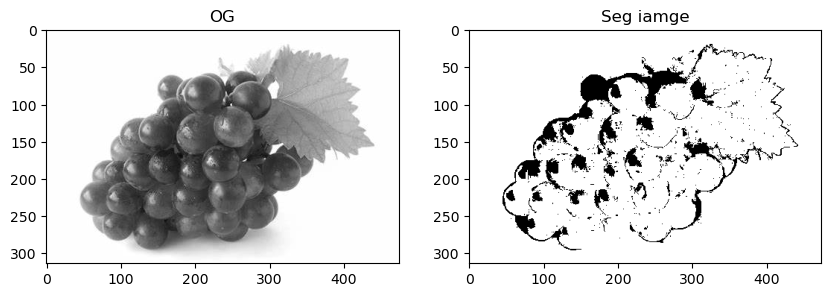

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_growing(img, seed, threshold=6):
    h, w = img.shape
    segmented = np.zeros_like(img, dtype=np.uint8)
    seed_list = [seed]
    
    while seed_list:
        x, y = seed_list.pop()
        if segmented[x, y] == 0:  # If not already visited
            segmented[x, y] = 255  # Mark as part of the region
            
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    if 0 <= x+dx < h and 0 <= y+dy < w:
                        if segmented[x+dx, y+dy] == 0:
                            if abs(int(img[x+dx, y+dy]) - int(img[x, y])) < threshold:
                                seed_list.append((x+dx, y+dy))
    
    return segmented

# Load image and convert to grayscale
image = cv2.imread('grapes.jpg', cv2.IMREAD_GRAYSCALE)

# Define seed point (modify as needed)
seed_point = (250,350)  # Example seed point

# Apply Region Growing segmentation
segmented_image = region_growing(image, seed_point)

# Display results
 

plt.figure(figsize=[10,5])
plt.subplot(121);plt.title('OG');plt.imshow(image,cmap='grey')
plt.subplot(122);plt.title('Seg iamge');plt.imshow(segmented_image,cmap='grey')

cv2.waitKey(0)
cv2.destroyAllWindows()
